## Week-3
### Notebook doing Exploratory Data Analysis (EDA) for the Bike rental data, along with Weather and Holidays Data

In [151]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [152]:
import sys
from pathlib import Path

# go to project root (parent of week-3)
project_root = Path.cwd().resolve().parent

# add src to Python path
sys.path.append(str(project_root / "src"))

In [153]:
sys.path

['/Users/JayeshManani/.local/share/uv/python/cpython-3.12.13-macos-aarch64-none/lib/python312.zip',
 '/Users/JayeshManani/.local/share/uv/python/cpython-3.12.13-macos-aarch64-none/lib/python3.12',
 '/Users/JayeshManani/.local/share/uv/python/cpython-3.12-macos-aarch64-none/lib/python3.12/lib-dynload',
 '',
 '/Users/JayeshManani/Downloads/MLOps-Level3/.venv/lib/python3.12/site-packages',
 '/Users/JayeshManani/Downloads/MLOps-Level3/src',
 '/Users/JayeshManani/Downloads/MLOps-Level3/src',
 '/Users/JayeshManani/Downloads/MLOps-Level3/src',
 '/Users/JayeshManani/Downloads/MLOps-Level3/src',
 '/Users/JayeshManani/Downloads/MLOps-Level3/src']

In [154]:
from bike_rental.defs.resources.project_config import ProjectConfig

cfgs = ProjectConfig()

In [155]:
cfgs.curated_path

'data/raw/curated_rental_dataset.csv'

In [156]:
data = pd.read_csv(f"../{cfgs.curated_path}")
data["datetime"] = pd.to_datetime(data["datetime"])
data = data.sort_values("datetime")

In [157]:
data.head()

,location_id,datetime,count_rentals,count_pickups,weekday,year,month,day,quarter,is_month_start,...,perceived_temperature_c,humidity,windspeed_kmh,conditions_clear,conditions_clouds,conditions_heavy_rain,conditions_light_rain,is_holiday,holiday_impact,deviation_from_normal
0,2,2011-01-01,0.0,1.0,5,2011,1,1,1,1,...,3.0,81.0,0.0,1.0,0.0,0.0,0.0,0,0.0,1.0
9,16,2011-01-01,1.0,0.0,5,2011,1,1,1,1,...,3.0,81.0,0.0,1.0,0.0,0.0,0.0,0,0.0,1.0
8,14,2011-01-01,0.0,1.0,5,2011,1,1,1,1,...,3.0,81.0,0.0,1.0,0.0,0.0,0.0,0,0.0,1.0
7,13,2011-01-01,2.0,0.0,5,2011,1,1,1,1,...,3.0,81.0,0.0,1.0,0.0,0.0,0.0,0,0.0,2.0
6,12,2011-01-01,2.0,0.0,5,2011,1,1,1,1,...,3.0,81.0,0.0,1.0,0.0,0.0,0.0,0,0.0,2.0


#### All the columns we have in the current dataset, we need to remove the count_rentals and count_pickups as we only want to predict per day bike estimation

In [158]:
data.columns

Index(['location_id', 'datetime', 'count_rentals', 'count_pickups', 'weekday',
       'year', 'month', 'day', 'quarter', 'is_month_start', 'is_month_end',
       'total_count', 'temperature_c', 'perceived_temperature_c', 'humidity',
       'windspeed_kmh', 'conditions_clear', 'conditions_clouds',
       'conditions_heavy_rain', 'conditions_light_rain', 'is_holiday',
       'holiday_impact', 'deviation_from_normal'],
      dtype='str')

In [159]:
# Dropping the Not Needed Columns
data = data.drop(columns=["count_rentals", "count_pickups"])
data.columns

Index(['location_id', 'datetime', 'weekday', 'year', 'month', 'day', 'quarter',
       'is_month_start', 'is_month_end', 'total_count', 'temperature_c',
       'perceived_temperature_c', 'humidity', 'windspeed_kmh',
       'conditions_clear', 'conditions_clouds', 'conditions_heavy_rain',
       'conditions_light_rain', 'is_holiday', 'holiday_impact',
       'deviation_from_normal'],
      dtype='str')

#### After Checking All the data, such as 

In [160]:
data.isnull().sum()

location_id                   0
datetime                      0
weekday                       0
year                          0
month                         0
day                           0
quarter                       0
is_month_start                0
is_month_end                  0
total_count                   0
temperature_c              3465
perceived_temperature_c    3465
humidity                   3465
windspeed_kmh              3465
conditions_clear           3465
conditions_clouds          3465
conditions_heavy_rain      3465
conditions_light_rain      3465
is_holiday                    0
holiday_impact                0
deviation_from_normal         0
dtype: int64

- We can see there are empty values specially in weather related datasets

In [161]:
data = data.dropna()

In [162]:
data.info()

<class 'pandas.DataFrame'>
Index: 364947 entries, 0 to 368411
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   location_id              364947 non-null  int64         
 1   datetime                 364947 non-null  datetime64[us]
 2   weekday                  364947 non-null  int64         
 3   year                     364947 non-null  int64         
 4   month                    364947 non-null  int64         
 5   day                      364947 non-null  int64         
 6   quarter                  364947 non-null  int64         
 7   is_month_start           364947 non-null  int64         
 8   is_month_end             364947 non-null  int64         
 9   total_count              364947 non-null  float64       
 10  temperature_c            364947 non-null  float64       
 11  perceived_temperature_c  364947 non-null  float64       
 12  humidity                 364947 

In [163]:
data.duplicated().sum()

np.int64(0)

In [164]:
data.describe()

,location_id,datetime,weekday,year,month,day,quarter,is_month_start,is_month_end,total_count,...,perceived_temperature_c,humidity,windspeed_kmh,conditions_clear,conditions_clouds,conditions_heavy_rain,conditions_light_rain,is_holiday,holiday_impact,deviation_from_normal
count,364947.000000,364947,364947.000000,364947.000000,364947.000000,364947.000000,364947.000000,364947.000000,364947.000000,364947.000000,...,364947.000000,364947.000000,364947.000000,364947.000000,364947.000000,364947.000000,364947.000000,364947.000000,364947.000000,364947.000000
mean,10.000005,2012-01-02 15:52:58.403439,3.011413,2011.502572,6.537897,15.683729,2.512088,0.033060,0.032966,9.022348,...,15.401530,62.722371,12.736603,0.656701,0.261474,0.000173,0.081653,0.028771,0.214191,8.808157
min,0.000000,2011-01-01 00:00:00,0.000000,2011.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,...,-16.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-13.339286
25%,5.000000,2011-07-04 23:00:00,1.000000,2011.000000,4.000000,8.000000,2.000000,0.000000,0.000000,2.000000,...,6.000000,48.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
50%,10.000000,2012-01-02 21:00:00,3.000000,2012.000000,7.000000,16.000000,3.000000,0.000000,0.000000,6.000000,...,16.000000,63.000000,13.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000
75%,15.000000,2012-07-02 07:00:00,5.000000,2012.000000,10.000000,23.000000,4.000000,0.000000,0.000000,13.000000,...,25.000000,78.000000,17.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,13.000000
max,20.000000,2012-12-31 23:00:00,6.000000,2012.000000,12.000000,31.000000,4.000000,1.000000,1.000000,64.000000,...,50.000000,100.000000,57.000000,1.000000,1.000000,1.000000,1.000000,1.000000,13.339286,64.000000
std,6.055275,NaN,2.001904,0.499994,3.438592,8.788868,1.114063,0.178792,0.178549,9.122896,...,11.341505,19.292534,8.196526,0.474811,0.439438,0.013138,0.273836,0.167163,1.404322,9.220812


<Axes: >

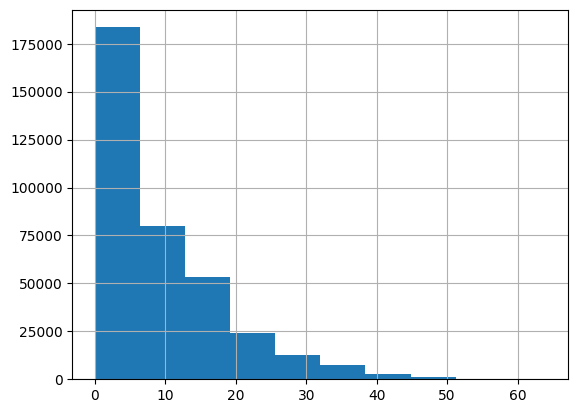

In [165]:
data["total_count"].hist(bins=10)

<Axes: >

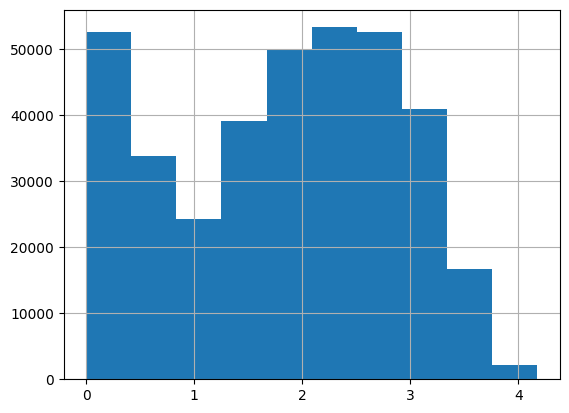

In [166]:
data["log_total_count"] = np.log1p(data["total_count"])
data["log_total_count"].hist(bins=10)

#### We can see around same time of the Year in both year it Increases and Decreases 

<Axes: xlabel='datetime'>

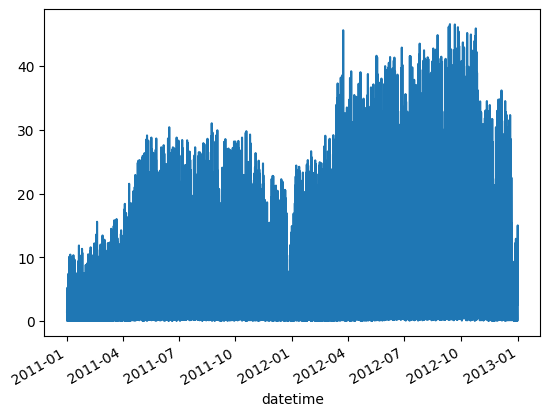

In [167]:
data.groupby("datetime")["total_count"].mean().plot()

In [168]:
data.groupby("weekday")["total_count"].mean()

weekday
0    8.750082
1    9.106614
2    9.101453
3    9.354127
4    9.339805
5    9.059327
6    8.450896
Name: total_count, dtype: float64

In [169]:
data.groupby("month")["total_count"].mean()

month
1      4.497917
2      5.374525
3      7.400511
4      8.917189
5     10.614631
6     11.453108
7     11.039042
8     11.337982
9     11.465388
10    10.578977
11     8.444544
12     6.776789
Name: total_count, dtype: float64

- We can see above mainly in summer there is higher demand overall compare to Year End and Start

<Axes: xlabel='temperature_c', ylabel='total_count'>

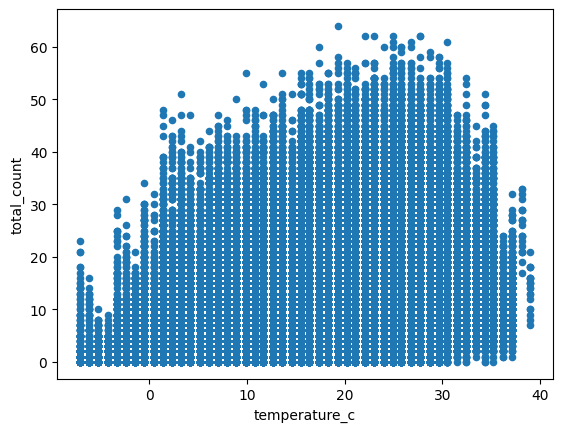

In [170]:
data.plot.scatter(x="temperature_c", y="total_count")

- If temperature is not so high and not so low, and good like between 15-35 there is higher demand overall

<Axes: xlabel='humidity'>

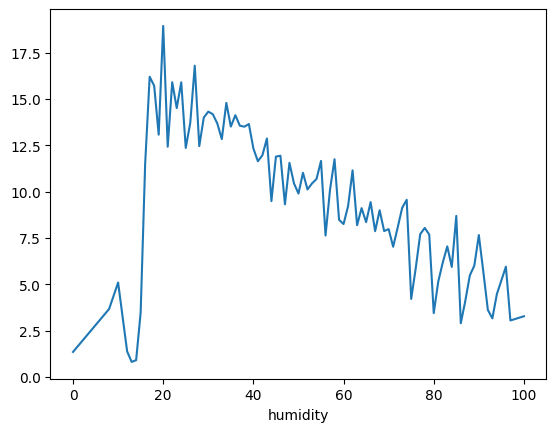

In [171]:
data.groupby("humidity")["total_count"].mean().plot()

In [172]:
data.groupby(
    ["conditions_clear", "conditions_light_rain", "conditions_heavy_rain"]
)["total_count"].mean()

conditions_clear  conditions_light_rain  conditions_heavy_rain
0.0               0.0                    0.0                      8.341214
                                         1.0                      3.539683
                  1.0                    0.0                      5.313299
1.0               0.0                    0.0                      9.756168
Name: total_count, dtype: float64

- We can see how demand decreases as the chances of raining increases
- clear > cloudy > light rain > heavy rain

In [173]:
data.groupby("is_holiday")["total_count"].mean()

is_holiday
0    9.068335
1    7.470000
Name: total_count, dtype: float64

- Due to holiday, there is slightly less demand compared to More holiday

<Axes: xlabel='temperature_c', ylabel='humidity'>

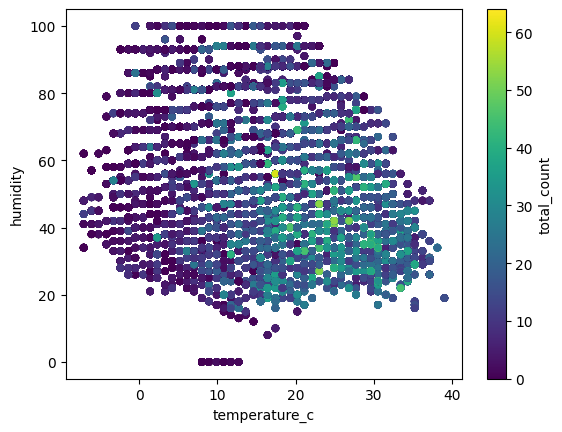

In [174]:
data.plot.scatter(x="temperature_c", y="humidity", c="total_count")

- We can see when temperature is good and Humidity is also not so high, There is high demand compared to High Humidity and High/Low Temperature

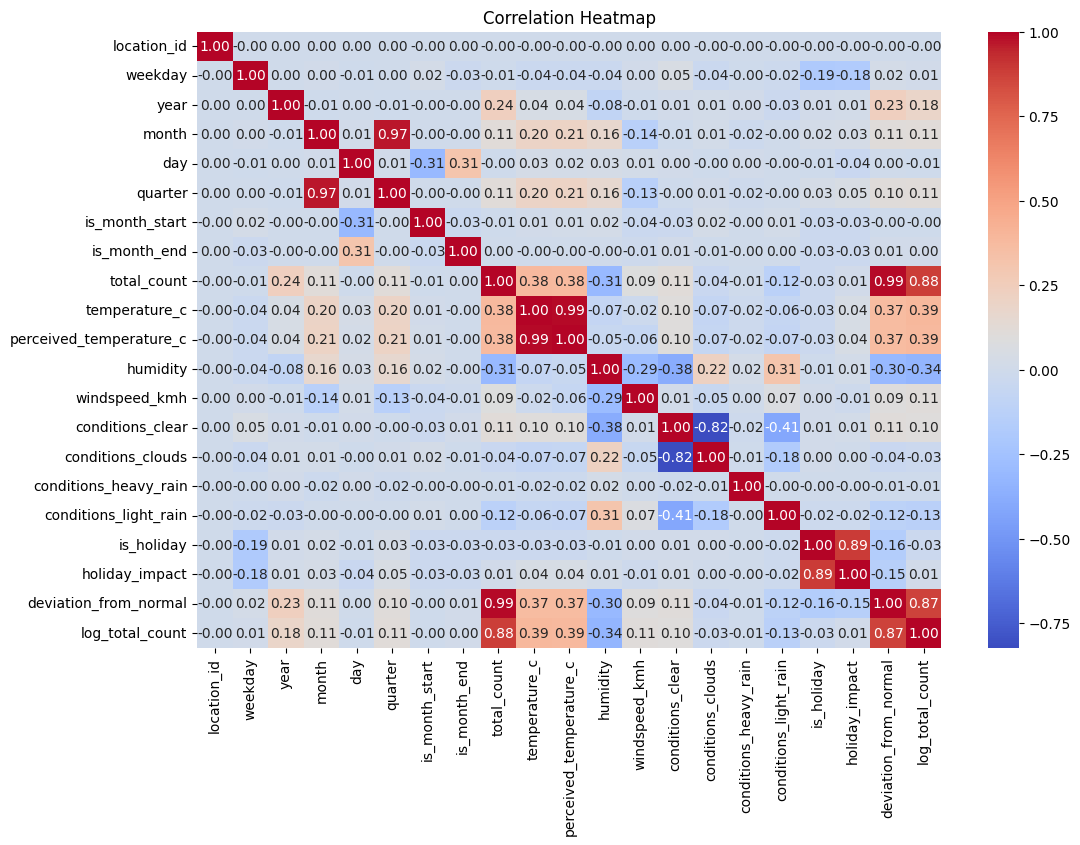

In [175]:
corr = data.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

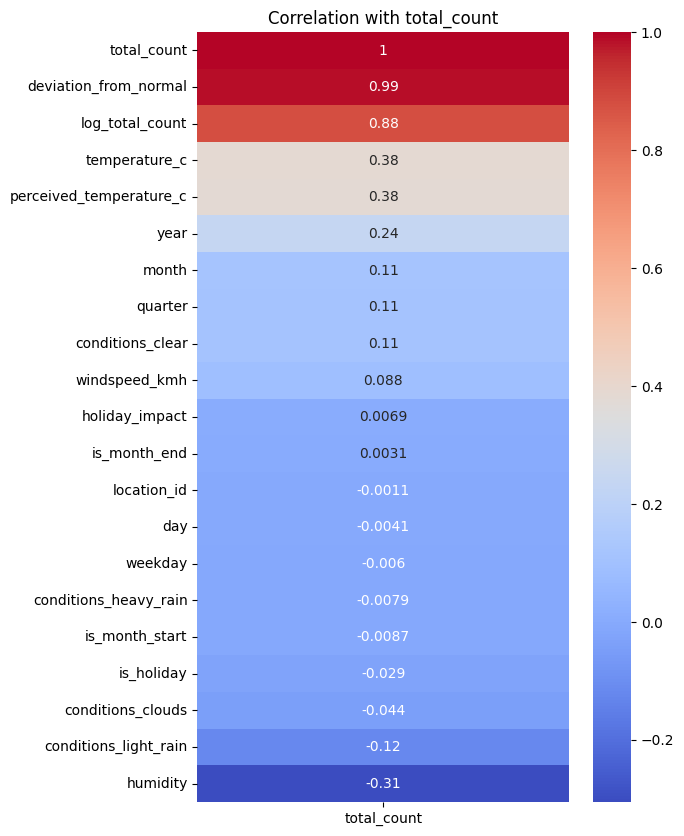

In [176]:
target_corr = data.corr(numeric_only=True)[["total_count"]].sort_values(
    by="total_count", ascending=False
)

plt.figure(figsize=(6, 10))
sns.heatmap(target_corr, annot=True, cmap="coolwarm")
plt.title("Correlation with total_count")
plt.show()